# 1. Обзор данных


Импортируем основные библиотеки для дальнейшей работы и постепенно начнем собирать информацию о нашем датасете. Нужно посмотреть распределения и найти выбросы, осознать их природу (плюс чтобы IQR например использовать нужно убедиться что распределение нормальное у признака). Выбросы ищем -> пропуски заполняем -> выбросы корректируем.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv('train.csv')

data.head()
data.shape

(1460, 81)

In [3]:
y = data["SalePrice"]
X = data.drop(columns=["SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

Реализуем общий интерфейс для исследования признаков. Для этого сделаем класс с понятным интерфейсом для изучения числовых признаков, а также отдельно получим список всех числовых признаков; при необходимости список может быть расширен, а новые числовые признаки (например замаскированные изначально под категориальные или полученные в ходе Feature Engineering) могут быть исследованы.

Выбросы будем искать с помощью IQR и визуализировать с помощью boxplot и scatter plot

Для уточнения природы выбросов есть return outliers

In [ ]:
class SimpleHandler:
  def __init__(self, dataframe, target):
    self.data = dataframe
    self.target = target


  def outline_detection_iqr(self, feature_name, return_outliners=False):
    #skewness coefficient add maybe from scipy
    feature = self.data[feature_name]
    iqr = feature.quantile(0.75) - feature.quantile(0.25)
    left_lim = feature.quantile(0.25) - 1.5*iqr
    right_lim = feature.quantile(0.75) + 1.5*iqr

    outliners = self.data.loc[(self.data[feature_name] < left_lim) | (self.data[feature_name] > right_lim), feature_name]

    print(f"total of {len(outliners)} outliners found, bonds: {left_lim}, {right_lim}")
    return outliners if return_outliners else None

  def visualize_feature(self, feature_name):
    #scatter maybe add and pearson
    #наследоваться от этого класса и сделать описатель для категориал признаков
    fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)
    axes[0].hist(self.data[feature_name], bins='auto')
    axes[0].axvline(x=self.data[feature_name].quantile(0.99))
    axes[1].boxplot(self.data[feature_name].dropna(), vert=False)
    axes[2].scatter(self.data[feature_name], self.target, alpha=0.3)

In [ ]:
X_train.select_dtypes(['number']).columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

total of 60 outliners found, bonds: -255.0, 425.0


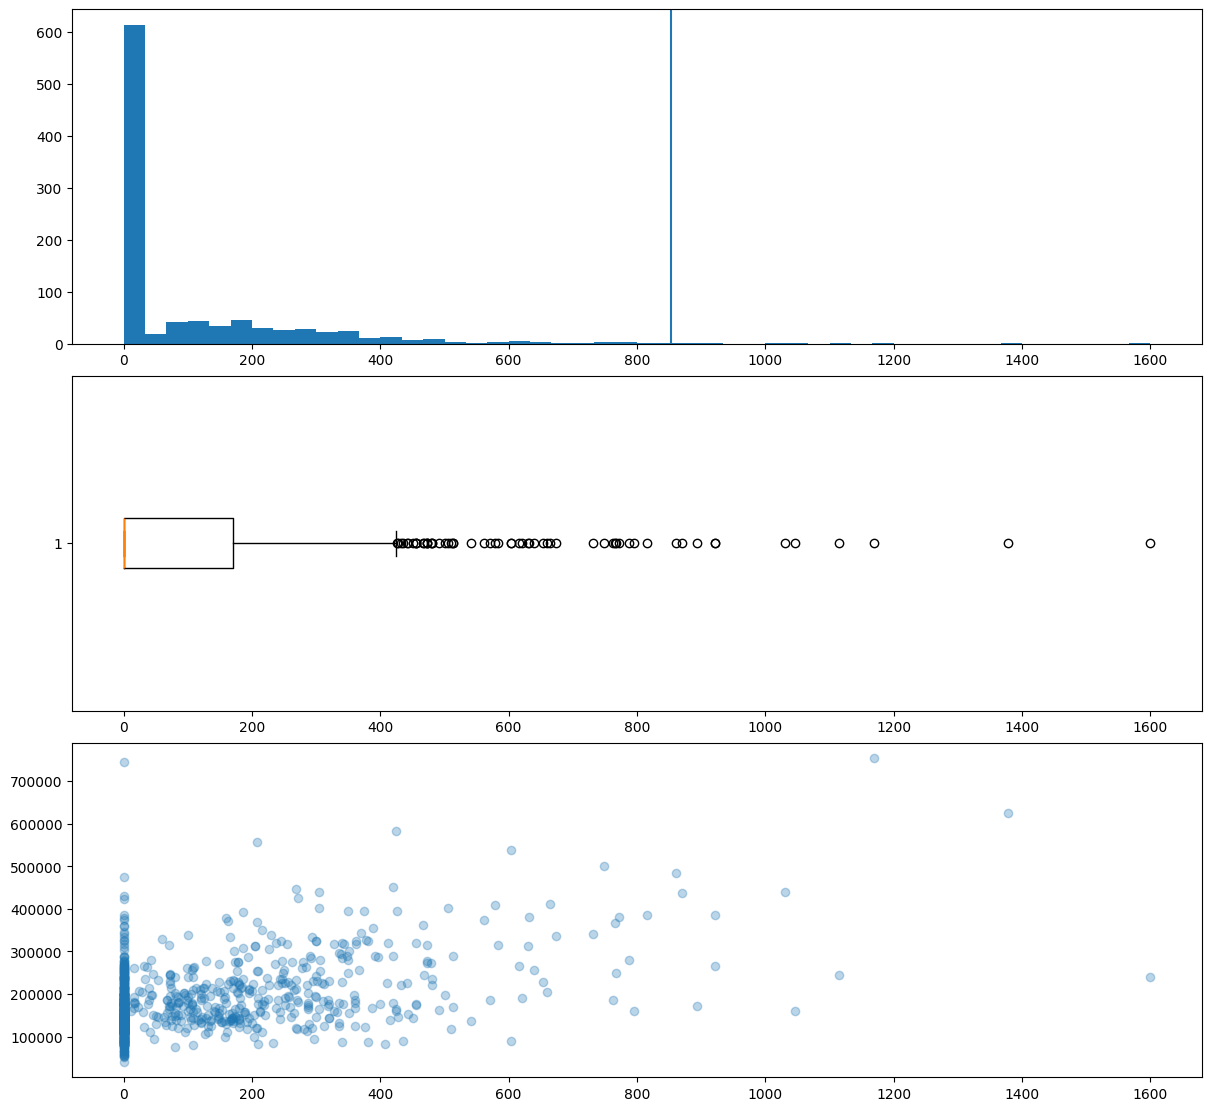

In [ ]:
test = SimpleHandler(X_train, y_train)

test.outline_detection_iqr('MasVnrArea', return_outliners=True).describe().T
#outliers_indexes = list(test.outline_detection_iqr('LotFrontage', return_outliners=True).index)
#X_train.loc[outliers_indexes]

test.visualize_feature('MasVnrArea')


С помощью встроенных методов библиотеки Pandas взглянем на пропуски в датасете.

In [ ]:
#скопировть ячейки снизу + график сиборн для пропусков чтобы увидеть структуру
missing_values_stat = pd.concat([
    X_train.isna().sum().to_frame('Количество пропусков'),
    (X_train.isna().sum() / len(data) * 100).to_frame('Процент пропусков'),
      X_train.dtypes.to_frame('Тип данных')
               ], axis=1)

missing_values_stat[missing_values_stat['Количество пропусков'] > 0].sort_values(by='Количество пропусков', ascending=False).T

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageType,GarageFinish,GarageQual,GarageYrBlt,GarageCond,BsmtQual,BsmtFinType2,BsmtExposure,BsmtCond,BsmtFinType1,MasVnrArea
Количество пропусков,1017,979,955,823,606,479,177,55,55,55,55,55,26,26,26,26,26,5
Процент пропусков,69.657534,67.054795,65.410959,56.369863,41.506849,32.808219,12.123288,3.767123,3.767123,3.767123,3.767123,3.767123,1.780822,1.780822,1.780822,1.780822,1.780822,0.342466
Тип данных,object,object,object,object,object,object,float64,object,object,object,float64,object,object,object,object,object,object,float64


**Промежуточный итог** исследования следующий: среди числовых данных присутствуют истинно числовые признаки, порядковые категориальные (представленные числами) + дата (года постройки). Отложим детальный разбор порядковых признаков и займемся обработкой выбросов и пропусков у числовых фичей и дат. Для этого сначала заведем списки признаков для которых требуется выполнить необходимые действия. К признакам, распределение которых скошено, применим логарифмическое преобразования с целью приведения их распределения к нормальному и, как следствие, более "плотной" компановке данных. Аномальные (сильно удаленные от основной массы наблюдений) значения признака у объектов заменим на 99 процентиль чтобы не терять информацию о большом их значении и в то же время сохранить способность модели линейной хорошо описывать типичные случаи - баланс. Явно неинформативные признаки в духе ID и признаки с высоким числом пропусков (например PoolQC) удалим.

Потенциально полезные признаки ***

Отдельно стоит обсудить пропуски в данном датасете. Согласно описанию признаков NA в некоторых категориальных означает не случайный пропуск а служит индикатором отсутствия чего-либо. Это также можно было заметить по одинаковому количеству пропусков в ряде родственных признаков (GarageType и год постройки его). **Во-первых** эти родственные признаки нужно использовать для осмысленного заполнения ряда случайных по своей природе пропусков в этих же родственных признаках. **Во-вторых** в таком случае полезно будет ввести новый признак-флаг говорящий о наличии/остутствия объекта описываемого данными признаками. Наконец **в-третьих** при оценке корреляции числового признака у которого имеются нули означающие также отсутствие чего-то будем опускать такие объекты для более верной оценке их влияния на трагет. Принятые решения о методах заполнения пропусков можно увидеть в реализации трансформера соответствующего.

In [4]:
#словари для категорий признаков
FEATURE_TYPE = {'Continuous': ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1'],
                'Discrete': ['BedroomAbvGr', 'TotRmsAbvGrd'],
                'Ordinal': ['OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd'],
                'Date': []}

ACTION_REQUIRED = {'BINNING': ['OverallQual', 'OverallCond', 'MoSold', 'TotRmsAbvGrd'],
                   'LOG_TRANSFORM': ['LotArea', 'GrLivArea', 'MasVnrArea', 'OpenPorchSF'],
                   'CLIPPING': ['LotFrontage', 'LotArea', 'MasVnrArea', 'TotalBsmtSF', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF'],
                   'FLAGGING': ['MasVnrArea', 'BsmtUnfSF', '2ndFlrSF', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea'],
                   'NEW_FEAT_BASED_ON': ['age', 'age_of_modif', 'good_basement_ratio', 'gr_base_ratio', 'total_baths', 'area_per_car'],
                   'DELETE': ['Id', 'MSSubClass', 'BsmtFinSF1', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', '3SsnPorch', 'ScreenPorch', 'MiscVal'],
                   'FILLINGNA': []}

Используя модули библиотеки sklearn реализуем часть необходимых для приведения данных к нужному виду трансформеров. При отсутствии сложной логики будем применять FunctionTransformer.

In [5]:
def log_selected_features(dataframe):
  data = dataframe.copy()
  feature_list = ACTION_REQUIRED['LOG_TRANSFORM']
  for feature in feature_list:
    mask = (data[feature] > 0) & (~data[feature].isna())
    data[feature] = data[feature].astype(float)
    data.loc[mask, feature] = np.log(data.loc[mask, feature])
    data.rename(columns={feature: f'log_{feature}'}, inplace=True)
  return data

def simple_feature_maker(dataframe):
      data = dataframe.copy()

      data['Age'] = data['YrSold'] - data['YearBuilt']
      data.loc[data['Age'] < 0, 'Age'] = 0


      data['RenovationAge'] = data['YrSold'] - data['YearRemodAdd']
      data.loc[data['RenovationAge'] < 0, 'RenovationAge'] = data['Age']

      data['FinBsmtRatio'] = (data['TotalBsmtSF'] - data['BsmtUnfSF']) / data['TotalBsmtSF']


      data['TotBaths'] = (
          data['BsmtFullBath'] +
          0.5 * data['BsmtHalfBath'] +
          data['FullBath'] +
          0.5 * data['HalfBath']
      )


      data['TotalPorchSF'] = data['OpenPorchSF'] + data['EnclosedPorch']


      return data

#не требуется  логика в fit методе в частности запоминание чего-то с train
log_transformer = FunctionTransformer(log_selected_features)
feat_gen_transformer = FunctionTransformer(simple_feature_maker)

In [6]:
#трансформермиксин позволяет реализовать дабл-метод fit_tranform при наличии 2х требуемых
class winsorizing_transformer(BaseEstimator, TransformerMixin):
  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    thresholds = []
    for feature in self.columns:
      thresholds.append(X[feature].quantile(0.99))
    self.thresholds_ = thresholds
    return self
    #зачем нижнее подчерк?

  def transform(self, X, y=None):
    X = X.copy()
    for feature, threshold in zip(self.columns, self.thresholds_):
      if X[feature].dtype == 'int64':
        X.loc[X[feature] > threshold, feature] = int(threshold)
      else:
        X.loc[X[feature] > threshold, feature] = threshold
    return X

In [7]:

class special_numeric_nan_handler(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.medians = []

  def fit(self, X, y=None):
    self.medians.append(X['MasVnrArea'].median())
    self.medians.append(X['LotFrontage'].median())
    return self

  def transform(self, X, y=None):
    X = X.copy()
    X.loc[X['MasVnrArea'].isna() & X['MasVnrType'].isna(), 'MasVnrArea'] = 0
    X.loc[X['MasVnrArea'].isna(), 'MasVnrArea'] = self.medians[0]
    X.loc[X['LotFrontage'].isna(), 'LotFrontage'] = self.medians[1]
    X.loc[X['GarageYrBlt'].isna(), 'GarageYrBlt'] = 0
    return X

In [ ]:
#эту дурилку строго перед подачей в модель юзать и после первого пайплайна
inbetween_transformer = ColumnTransformer(
    transformers = [
    ('simpleimputer', SimpleImputer(strategy='median'), list(X_train.select_dtypes(['number']).columns)),
    ('scaling', StandardScaler(), list(X_train.select_dtypes(['number']).columns))
])

In [8]:
#результат применения column_трансформера это npndarray а не data frame! трансформеров надо пихать в пайплайны! чтобы выход был DF

first_pipeline = Pipeline([
    ('new_features', feat_gen_transformer),
    ('clipping', winsorizing_transformer(columns=ACTION_REQUIRED['CLIPPING'])),
    ('numeric_nan_t', special_numeric_nan_handler()),
    ('log', log_transformer)
    ])

first_pipeline.fit(X_train)
X_train = first_pipeline.transform(X_train)

In [ ]:
inbetween_transformer.set_output(transform='pandas')

inbetween_transformer.fit(X_train)
X_train = inbetween_transformer.transform(X_train)

# Работа с числовыми признаками

Для начала узнаем какие признаки наиболее сильно линейно связаны с целевой переменной, для чего посчитаем коэффицинт корреляции Пирсона.

Надо помнить что коэффициент Пирсона говорит лищь о наличии линейной связи, то есть у нас могут быть признаки, от который целейвая переменная зависит нелинейно - для этого отдельно рассмтрим оставшиеся после "начального отбора" признаки путем построения scatter plot for each one. При фиксации какой-либо структуры попытаемся модифицировать такие признаки/обработать.
Не стоит правда борщить ибо можно приехать к переобучению.

МУЛЬТИКОЛЛИНЕАНОСТЬ СРЕДИ ОТОБРАННЫХ!!


подбор гиперпараметров в регуляризации
чистка выбросов? как и почему?
пояснить выбор метрики?

НЕ ЗАБЫТЬ ПРО CV
проверка остатков в конце - по предположению модели остатки должны быть распределены нормально?? почитать короче про это

Нормальное распределение признаков (X) — НЕ ТРЕБУЕТСЯ. Это миф.
Нормальное распределение целевой переменной (y) — ЖЕЛАТЕЛЬНО, если мы строим статистические выводы, но не обязательно для предсказаний.Нормальное распределение остатков (ошибок) — ВАЖНО для проверки качества модели и статистической значимости

проверка нормальности распределения таргета + графики seaborn "дуальные"

Взаимная информация (Mutual Information); учитывать еще взаимодействие признаков и то что составной признак из двух "плохих" может хорошо влиять на таргет

План работы:
1) найти лучшую константу - это будет baseline (быть может стоит придумать bl лучше чтобы явно понять какие навороты к модели ее улучшают)

baseline - отобранные признаки по пирсону без новых и флагов.
2) посмотреть на лучшие "линейные" признаки и ее результат + мультиколлинеар
3) добавить "нелинейные"
4) трайнуть регуляризацию
5) обработать категориальные признаки (как их вообще анализировать и их влияние на модель)?
6) тоже регуляризация пробуем

In [9]:
#выбираем числовые признаки
numeric_features = X_train.select_dtypes(['number'])


Предварительно отбираем:

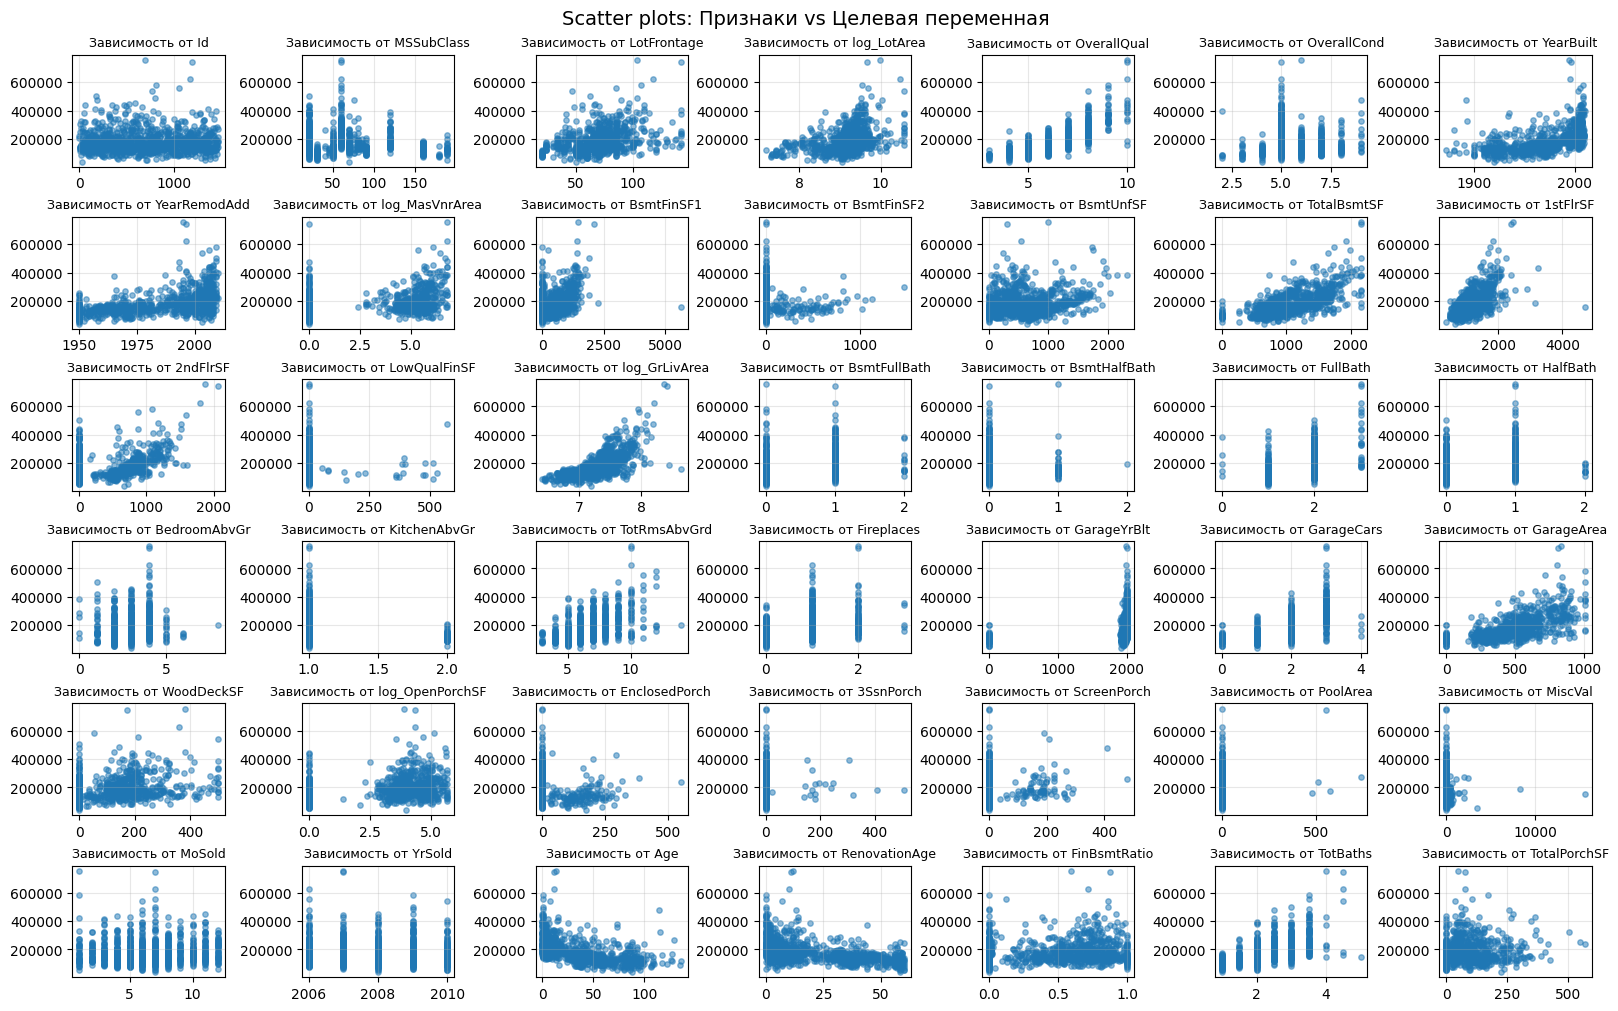

In [10]:
import math

n_features = len(numeric_features.columns)
n_cols = math.ceil(math.sqrt(n_features))
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)
axes = axes.flatten() if n_features > 1 else [axes]

for idx, column in enumerate(numeric_features.columns):
    axes[idx].scatter(numeric_features[column], y_train, alpha=0.5, s=15)
    axes[idx].set_title(f'Зависимость от {column}', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

# Удаляем лишние подграфики
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Scatter plots: Признаки vs Целевая переменная', fontsize=14)
plt.show()

**Короче видим явно и вспоминаем что у некоторых признаков есть 0 означающие пропуск - надо это дело фильтрнауть ибо такие нули сильно вредят здравой оценке расчета корреляции**

In [11]:
mask = (
    (numeric_features['log_MasVnrArea'] > 0) &
    (numeric_features['log_OpenPorchSF'] > 0) &
    (numeric_features['2ndFlrSF'] > 0) &
    (numeric_features['GarageYrBlt'] > 0) &
    (numeric_features['GarageArea'] > 0) &
    (numeric_features['TotalBsmtSF'] > 0) &
    (numeric_features['WoodDeckSF'] > 0) &
    (numeric_features['FinBsmtRatio'] > 0) &
    (numeric_features['TotalPorchSF'] > 0)
)

In [13]:
pearson_values = numeric_features[mask].corrwith(y_train).sort_values(ascending=False)
pearson_values

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
TotalBsmtSF,0.679161
OverallQual,0.672317
FullBath,0.630491
GarageCars,0.624174
log_GrLivArea,0.617451
TotRmsAbvGrd,0.601348
2ndFlrSF,0.592364
GarageArea,0.584750
TotBaths,0.546576
log_LotArea,0.506095


Сильные коэффциенты корреляции соотвествуют наличию направления на scatter plots конкретного признака. Детектируются выбросы, лежащие вне линии тренда на таких графиках. Каких-то явнвых нелинейных зависимостей не прослеживается, возможно строить полиномиальные признаки не стоит.

Оценим взаимодействия признаков путем построения матрицы корреляций

In [26]:
corr_matrix = X_train.select_dtypes(['number']).corr() #это датафрейм а не спешл объект
corr_matrix
#corr_matrix[abs(corr_matrix) > 0.75]

,Id,MSSubClass,LotFrontage,log_LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,log_MasVnrArea,BsmtFinSF1,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,Age,RenovationAge,FinBsmtRatio,TotBaths,TotalPorchSF
Id,1.000000,0.032361,-0.039670,-0.022113,-0.031187,0.011890,-0.010156,-0.035649,-0.034606,0.014095,...,0.002073,0.060214,-0.008276,0.022212,0.057775,0.012643,0.039360,0.020829,0.037556,0.017359
MSSubClass,0.032361,1.000000,-0.398522,-0.501684,0.025309,-0.057093,0.022191,0.035759,0.029845,-0.076917,...,-0.011462,0.024108,-0.005904,-0.004700,-0.020816,-0.023063,-0.037133,0.013658,0.136111,-0.026592
LotFrontage,-0.039670,-0.398522,1.000000,0.633735,0.258195,-0.084298,0.145043,0.097276,0.152989,0.173703,...,0.029559,0.139863,0.000888,0.024907,0.000310,-0.144842,-0.097248,0.013527,0.245256,0.146781
log_LotArea,-0.022113,-0.501684,0.633735,1.000000,0.205075,-0.004822,0.022188,0.044185,0.076221,0.214708,...,0.098736,0.105279,0.048348,0.037030,-0.030236,-0.023468,-0.046034,0.031377,0.246421,0.151265
OverallQual,-0.031187,0.025309,0.258195,0.205075,1.000000,-0.125678,0.571197,0.537714,0.398956,0.218583,...,0.061780,0.083957,-0.035804,0.088912,-0.016450,-0.571168,-0.539371,-0.071659,0.543313,0.181004
OverallCond,0.011890,-0.057093,-0.084298,-0.004822,-0.125678,1.000000,-0.381166,0.033249,-0.166328,-0.042715,...,0.085902,-0.001552,0.082691,-0.036042,0.072607,0.383814,-0.028689,0.055432,-0.190804,0.023965
YearBuilt,-0.010156,0.022191,0.145043,0.022188,0.571197,-0.381166,1.000000,0.590034,0.403938,0.231988,...,-0.068263,0.002085,-0.036597,0.040405,-0.008338,-0.999063,-0.591324,0.100031,0.514853,-0.123149
YearRemodAdd,-0.035649,0.035759,0.097276,0.044185,0.537714,0.033249,0.590034,1.000000,0.205118,0.119295,...,-0.041248,0.001466,-0.001781,0.039591,0.052607,-0.586992,-0.997971,-0.039653,0.454500,0.061843
log_MasVnrArea,-0.034606,0.029845,0.152989,0.076221,0.398956,-0.166328,0.403938,0.205118,1.000000,0.219537,...,0.016374,-0.026968,-0.050795,0.044926,-0.015859,-0.404100,-0.206332,0.094654,0.297644,-0.023562
BsmtFinSF1,0.014095,-0.076917,0.173703,0.214708,0.218583,-0.042715,0.231988,0.119295,0.219537,1.000000,...,0.063864,0.177146,0.001242,-0.021094,-0.002840,-0.231810,-0.119457,0.776463,0.457026,0.023487


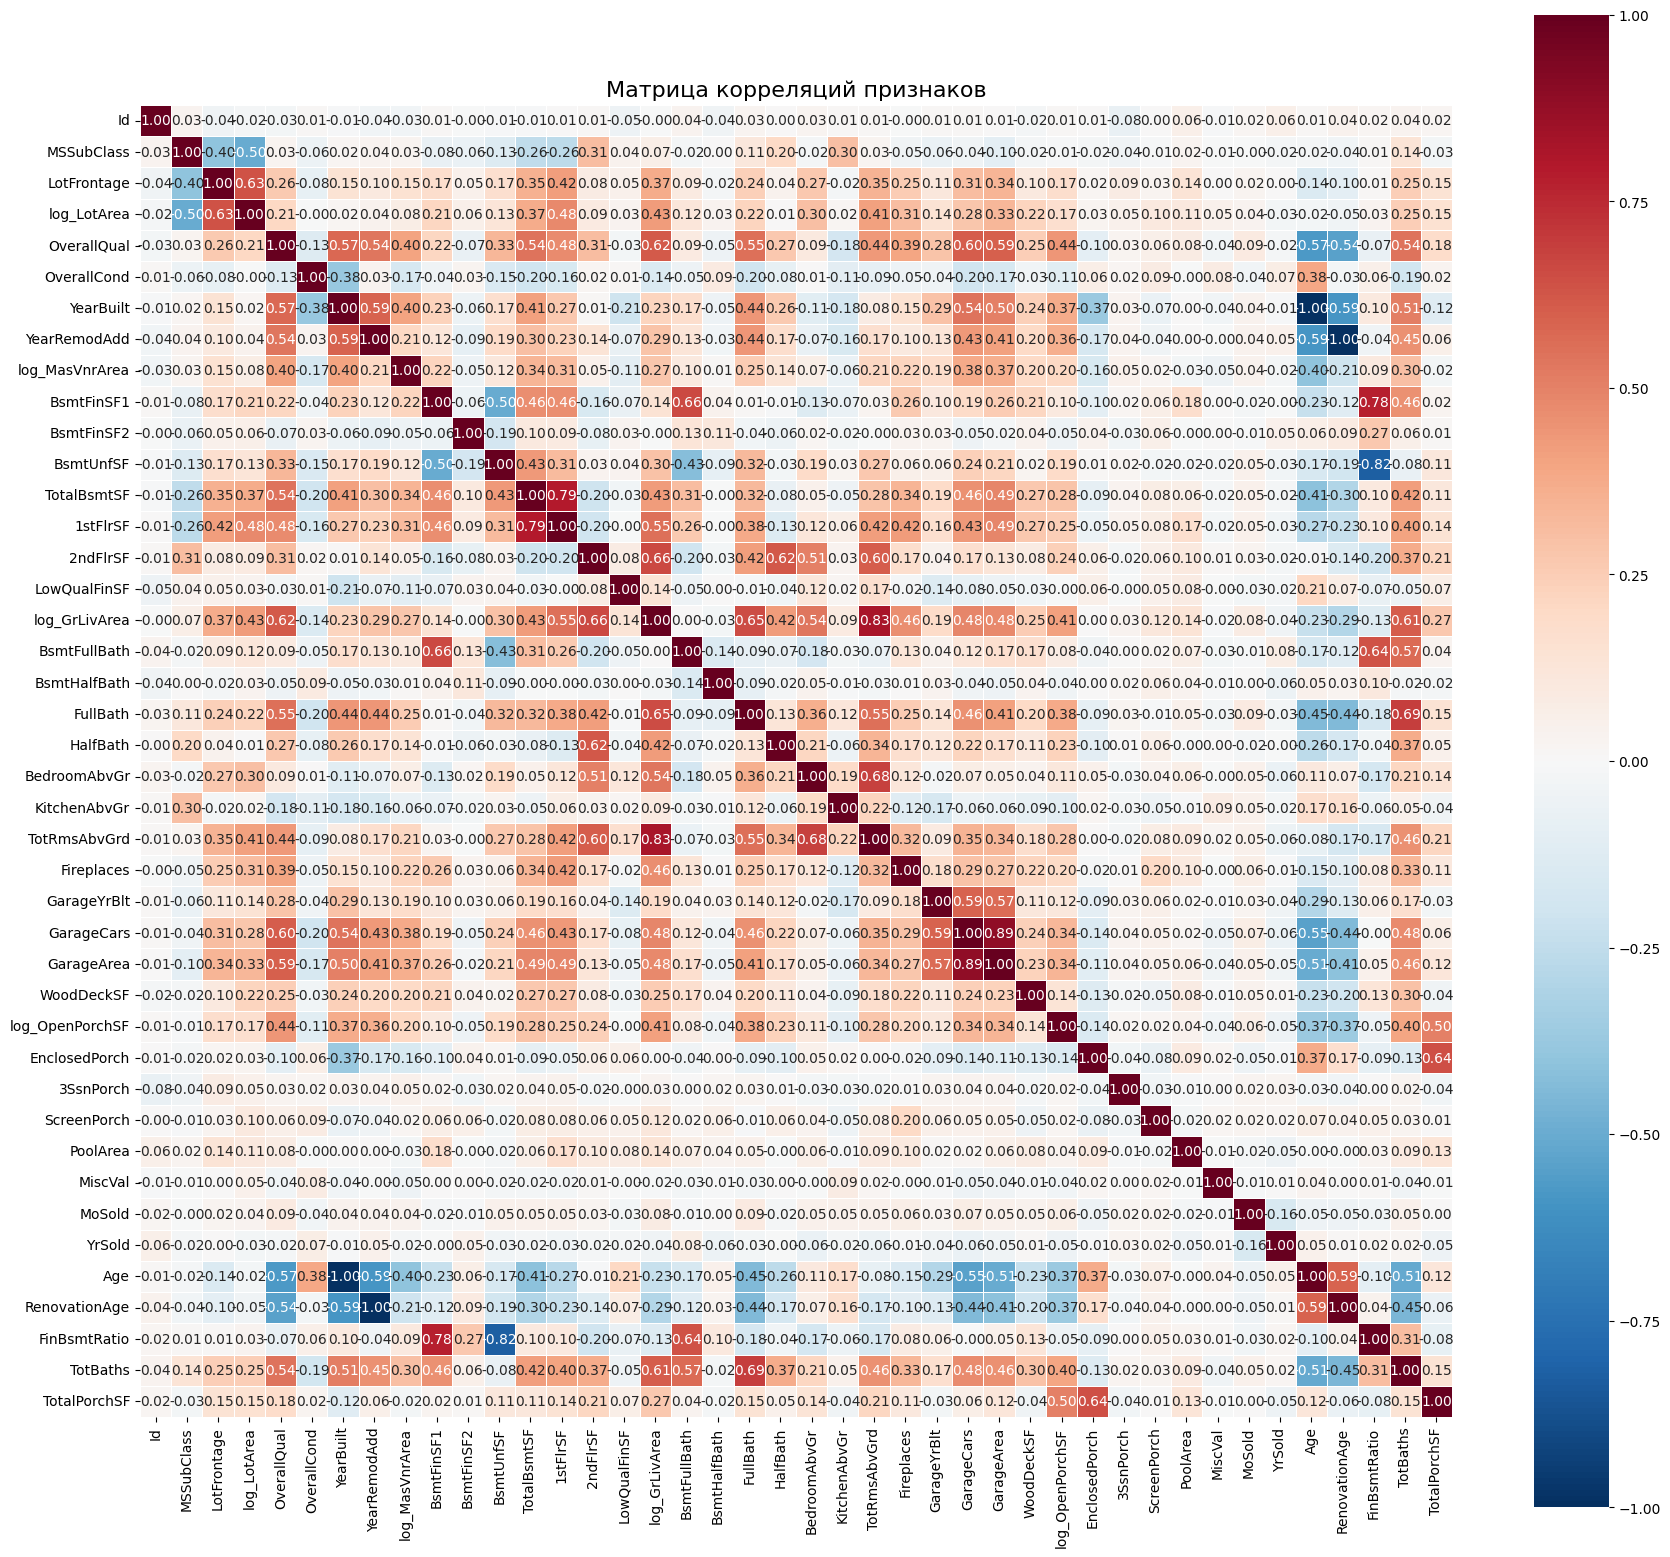

In [ ]:
import seaborn as sns

plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix,
            annot=True,           # показывать значения
            cmap='RdBu_r',        # цветовая схема (красный-синий)
            center=0,             # центр в 0
            vmin=-1, vmax=1,       # границы от -1 до 1
            square=True,           # квадратные ячейки
            fmt='.2f',             # формат чисел
            linewidths=0.5)        # линии между ячейками
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

Все признаки, у которых корреляция с таргетом по абсолютному значению меньше 0.3, использовать не будем. Аналогично отбросим взаимодействующие признаки со взаимной корреляцией более 0.75

In [42]:
#получим списки того что нужно выкинуть
pearson_drop_features = list(pearson_values[abs(pearson_values) < 0.3].index)

pearson_drop_features
multicol_drop_features = ['YearBuilt', 'YearRemodAdd', 'TotRmsAbvGrd', 'GarageArea']

#FinBsmtRatio вроде более информативен чем BsmtFinSF1
#YearBuilt vs Age -  у Age чуть больше корел + объяснить проще
#same с RenovationAge и YearRemodAdd
#totalroomsaboveground убираем
#соотношение площадей 1 и 2 этажей мб сделать
#garage area vs garagecars - выбираем второе


,BsmtFinSF1
912,489
373,428
20,0
800,462
152,416
...,...
1393,0
1344,0
527,1330
1149,624


# 3. Категориальные признаки

Аналогично проведем исследование категориальных признаков не забывая отедельно посмотреть на представленые числами категориальные признаки. Для оценки потенциального влияния категориального признака на таргет используем ANOVA тест, для чего реализуем соответствующий класс.

По результатам ANOVA и рассчетов Пирсона + мульколлинеарности составим список признаков которые не будут включены в модель.

В соответствии с результатами изучения пропусков и принятыми решениями о стратегии их заполнения реализуем хендлеры для соответствующих категориальных признаков.

А что с выбросами? Категория "прочее"?

Момент с OHE: поскольку у некоторых признаков есть особый флаг наличия и тип объекта который "в наличии" то. Короче желехма надо выбросить как-то именно флаг который в категории объекта будет за No отвечать. Ну и если есть категория No где-то в признаке то процедуру такую для него проводим. В остальных же просто дропаем первый дамми-признак

In [30]:
def flag_maker(data):
  data = data.copy()
  data['Has2ndFlr'] = np.where(data['2ndFlrSF'] > 0, 1, 0)
  data['HasGarage'] = np.where(data['GarageFinish'].isna(), 0, 1)
  data['HasBsmt'] = np.where(data['BsmtQual'].isna(), 0, 1)
  data['HasVnr'] = np.where(data['MasVnrType'].isna(), 0, 1)
  data['HasPorch'] = np.where(data['TotalPorchSF'] > 0, 1, 0)
  return data

X_train = flag_maker(X_train)

In [31]:
#выберем все категориальные фичи
categorial_features = X_train.select_dtypes(['object']) #это новый датафрейм из вбранных колонок!!
categorial_features.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
912,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Abnorml
373,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,GdWo,NaN,WD,Normal
20,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NridgHt,Norm,...,BuiltIn,RFn,TA,TA,Y,NaN,NaN,NaN,New,Partial
800,RL,Pave,NaN,IR1,HLS,AllPub,Inside,Mod,ClearCr,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,Shed,WD,Normal
152,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,GdWo,NaN,WD,Normal


Визуально изучим категориальные признаки признаки в том числе отдельно посмотрим и на признаки-флаги. Для этого используем библиотеку seaborn

In [ ]:
class categorial_feat_visual:
  def __init__(self, data, target):
    self.data = data
    self.target = target

  def visualize_feature(self, feature_name):
    sns.catplot(data=self.data, x=feature_name, y=self.target, kind='box')
    #по умолчанию думаю скипаются пропуски при построении графика
    #указка рарных категорий - проценты по всем


In [ ]:
class anova_stat_test:
  def __init__(self, data, target):
    self.data = data
    self.target = target
    self.ssb = 0
    self.ssw = 0
    self.k = 0

  def variance_calculation(self, feature_name):
    self.ssb, self.ssw, self.k = 0, 0, 0
    groups = self.data[feature_name].groupby(self.data[feature_name]).indices
    self.k = len(groups)
    for key in groups:
      self.ssb += len(groups[key]) * (self.target.iloc[groups[key]].mean() - self.target.mean()) ** 2
      self.ssw += ((self.target.iloc[groups[key]] - self.target.iloc[groups[key]].mean()) ** 2).sum()

    #k - кол-во групп; N -общий размер выборки
    #значимые по резам anova окрасить в зеленый другие в красный или градиент

  def one_way_anova(self, feature_name):
    self.variance_calculation(feature_name)
    f_score = (self.ssb / (self.k - 1)) / (self.ssw / (len(self.target) - self.k))
    p_val = 1 - stats.f.cdf(f_score, self.k - 1, len(self.target) - self.k)
    return f_score, p_val



<Axes: xlabel='None', ylabel='None'>

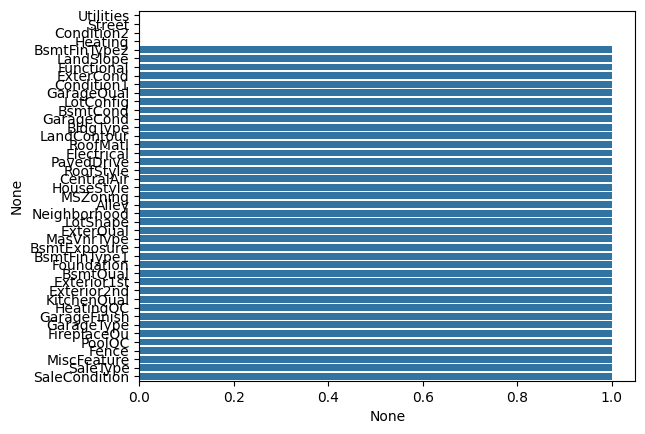

In [ ]:
anova_results = {}
ANOVA = anova_stat_test(categorial_features, y_train)
for column in categorial_features.columns:
  anova_results[column] = ANOVA.one_way_anova(column)[1]

anova_results = pd.Series(anova_results).sort_values(ascending = False) <= 0.05
anova_results
#sorted_features =
sns.barplot(y=anova_results.index, x=anova_results)

In [ ]:
ANOVA = anova_stat_test(categorial_features, y_train)
ANOVA.one_way_anova('LotShape')

(np.float64(28.23200393972582), np.float64(1.1102230246251565e-16))

На основе данных полученных с помощью ANOVA и выводов из пункта про числовые признаки сделаем простой трансформер отбрасывающий нужные колонки

In [43]:
#трансформер для отбрасывания идет перед OHE
#нужны списки!
#либо много пропусков PoolQC
#либо ANOVA + мультикол
#либо пирсон + мультикол
columns_to_drop = {
    #'ANOVA': [],
    'PEARSON': pearson_drop_features,
    'MULTICOL': multicol_drop_features,
    'MANYNANS': ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
}

def dropper(X, columns_to_drop=None):
  #columns_to_drop is dict
  X = X.copy()
  for reason in columns_to_drop:
    X = X.drop(columns=columns_to_drop[reason])

  return X

drop_transformer = FunctionTransformer(func=dropper, kw_args={'columns_to_drop': columns_to_drop})

In [45]:
X_train['Alley']

,Alley
912,NaN
373,NaN
20,NaN
800,NaN
152,NaN
...,...
1393,Pave
1344,NaN
527,NaN
1149,NaN


Коэффициент Крамера - для отбора коррелирующих категориальных признаков!! Выбросы\? Пропуски? Общиий хендлер новых пропусков?  Mutual Information?

In [ ]:
#построение и реализация матрицы крамера для отбора признаков



Не забудем также про особое заполение пропусков ряде категориальных признаков

In [32]:
list_of_nAn = ['MasVnrType', 'FireplaceQu', 'GarageType',	'GarageFinish', 'GarageQual',	'GarageCond',	'BsmtQual',	'BsmtFinType2', 'BsmtExposure',	'BsmtCond', 'BsmtFinType1']
#надо учесть удаляемые колонки

def special_nan_categor_handle(dataframe):
  dataframe = dataframe.copy()
  dataframe = dataframe.fillna('No')
  return dataframe

special_nan_categor_trans = FunctionTransformer(special_nan_categor_handle)

In [48]:
#НЕ ЗАБЫТЬ df.drop (колонки с 'No' в назавании)
#list(X_train.select_dtypes(['object']).columns)
#columns_to_drop = [col for col in df.columns if '_Тверь' in col]

categorial_transformer = ColumnTransformer(
    transformers = [
        ('specailnan', special_nan_categor_trans, list_of_nAn),
        ('simpleimputer', SimpleImputer(strategy='most_frequent'), list(X_train.columns)),
        ('onehotenc', OneHotEncoder(drop='first', sparse_output=False), list(X_train.columns))
])

categorial_transformer.set_output(transform='pandas')

#categorial_transformer.fit(X_train)
#X_train = categorial_transformer.transform(X_train)

ColumnTransformer(transformers=[('specailnan',
                                 FunctionTransformer(func=<function special_nan_categor_handle at 0x79c7f10cf060>),
                                 ['MasVnrType', 'FireplaceQu', 'GarageType',
                                  'GarageFinish', 'GarageQual', 'GarageCond',
                                  'BsmtQual', 'BsmtFinType2', 'BsmtExposure',
                                  'BsmtCond', 'BsmtFinType1']),
                                ('simpleimputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['MSZoning', 'log_...
                                  'LotShape', 'LandContour', 'Utilities',
                                  'LotConfig', 'LandSlope', 'Neighborhood',
                                  'Condition1', 'Condition2', 'BldgType',
                                  'HouseStyle', 'OverallQual', 'RoofStyle',
                                  'RoofMatl', 'Exterior1st', 'Exterior2nd',
                                  'MasVnrType', 'log_MasVnrArea', 'ExterQual',
                                  'ExterCond', 'Foundation', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'BsmtUnfSF', 'TotalBsmtSF', ...])])

In [49]:
second_pipeline = Pipeline([
    ('drop_transformer', drop_transformer),
    ('columnbased_categorial_transformer', categorial_transformer)
])

second_pipeline.fit(X_train)
X_train = second_pipeline.transform(X_train)

KeyError: "['BedroomAbvGr', 'Fireplaces', 'LotFrontage', 'Id', 'BsmtFinSF1', 'BsmtFullBath', '3SsnPorch', 'ScreenPorch', 'BsmtFinSF2', 'YrSold', 'FinBsmtRatio', 'MoSold', 'OverallCond', 'log_OpenPorchSF', 'HalfBath', 'EnclosedPorch', 'PoolArea', 'MiscVal', 'TotalPorchSF', 'MSSubClass'] not found in axis"

In [47]:
X_train['Alley']

KeyError: 'Alley'

# 4. Baseline линейной модели

In [ ]:
#скейлер + выкинуть ряд колонок + imputer в первый пайплайн загнать + общий пайплайн для test
X_train = X_train.drop([], axis=1)

In [ ]:
#линрег!! и кроссвалид

baseline_linear_reg = LinearRegression()
baseline_linear_reg.fit(X_train, y_train)

In [ ]:
X_test = first_pipeline.transform(X_test)
X_test = complex_numeric_transformer.transform(X_test)
X_test = categorial_transformer.transform(X_test)

In [ ]:
# Предсказание на тестовых данных
y_pred = baseline_linear_reg.predict(X_test)

# Оценка качества модели на отложенной выборке
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Нужно понять достаточно ли хорошо обучена модель: переобучена или недообучена или баланс. Bias = недо (систематически ошибается); Variance = пере (под шум подстраивается; дает очень разнозненный предсказания по величине видимо; или тут речь про дисперсию коэффициентов?)

In [ ]:
#LASSO + RIDGE + CV для всех + сравнение результатов + анализ ошибок (теорвер) у лучшей + вопрос интерпретации

высший пилотаж: fastapi (web сервис) + docker + sqllite/alchemy для подсоса данных + optuna + pickle; базово надо завести логи и сохранить модель + биннинг